# Abalone Age Prediction – Complete Analysis and Modeling Notebook
### Combined Dataset Processing, EDA, Preprocessing, Regressor Comparison, ANN Architectures, and Evaluation
___
<h1 style="text-align:center;">NOTICE</h1>  
I'm sorry to inform that due to lack of more time this notebook is currently in a incomplete state. Most of the intended coding solutions have been implemented and should work properly, with the exemption ANN implementation which is incomplete.  
What is lacking in the notebook is mainly:

- Descriptive markdown text for some code.
- Graphical plots to illustrate and evaluate models.
- Descriptive evaluations of some result and a final discussion on findings and potentiall improvments for further work.
- Implementation, training and evaluation of ANN models.
- Final comparison of all models including ANN models.

___

This notebook merges all work from previous notebooks and adds the missing sections required for the assignment.


# Mandatory: Supervised Learning II
## Description and exploratory analysis of the 'Abalone Age Prediction' dataset.
In this document, we'll be using the "Abalone Age Prediction" dataset which was appended in the course resources to perform exploratory data analysis (EDA) and preprocessing.

### Purpose of the Dataset
The purpose of the "Abalone Age Prediction" dataset is to predict the age of abalones from physical measurements. This can help in understanding the growth patterns of abalones and can be useful for fisheries management and conservation efforts.

### Dataset Overview
The dataset consists of several features that describe the physical characteristics of abalones, along with a target variable that indicates their age. The features include measurements such as length, diameter, height, whole weight, shucked weight, viscera weight, shell weight, and sex of the abalone.  
All features are numeric except for the "Sex" feature, which is categorical and indicates whether the abalone is male, female, or infant.

## Feature Description
The dataset contains the following features:
| Feature       | Type   		| Description   | Units   |
| ------------- | ------------- | ------------- | ------------- |
| Sex | Categorical	| M, F, and I (infant)	| mm    |
| Lenght | Continuous	| Longest shell measurement	| mm    |
| Diameter | Continuous	| perpendicular to length	| mm    |
| Height | Continuous	| with meat in shell	| grams |
| Whole_weight | Continuous	| whole abalone	| grams |
| Shucked_weight | Continuous	| weight of meat	| grams |
| Viscera_weight | Continuous	| gut weight (after bleeding)	| grams |
| Shell_weight | Continuous	| after being dried	| grams |


## Target Variable
Target variable is labled "Rings", has a numeric value.  
If I've understood the data correctly then the given target value + 1.5 should give the age if the Abalone.
| Target       | Type   		| Description   |
| ------------- | ------------- | ------------- |
| Rings | Integer	| +1.5 gives the age in years |


## Exploratory Data Analysis (EDA)
In this section, we will perform exploratory data analysis to understand the distribution of features and the target variable, as well as identify any potential correlations or patterns in the data.
### Data import
We'll start by importing the necessary libraries to analyze the dataset and loading the dataset with pandas.  
For this analysis, we'll be dropping the target variable from the dataset to focus on the features only.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Custom Functions for Analysis
To facilitate the analysis of the dataset, we'll define some custom functions that can help us visualize and understand the data better.

In [2]:
def get_df_name(df):
    name =[x for x in globals() if globals()[x] is df][0]
    return name

def corr_matrix(df):
    numCorr1 = df.corr()
    fig, ax = plt.subplots(1,1, figsize=(23,7))
    sb.heatmap(numCorr1, annot=True, cmap='coolwarm', ax=ax)
    ax.set_title(get_df_name(df))

def target_bar(df1):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sb.countplot(x="Target", data=df1, ax=ax)
    ax.set_title(get_df_name(df1))
    ax.set_xlabel("Target")
    ax.set_ylabel("Count")
    plt.tight_layout()


In [3]:
abalone_df = pd.read_csv('../data/abalone.csv', sep=',', names=[
    "sex",
    "length",
    "diameter",
    "height",
    "whole_weight",
    "shucked_weight",
    "viscera_weight",
    "shell_weight",
    "rings"
])
abalone_df_X = abalone_df.drop(columns=['rings'])
abalone_df_y = abalone_df[['rings']]
abalone_df.head()

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


### Validation of Data types
#### Dataset Information
It's important to validate that the data types of each feature are appropriate for analysis.  
We can use the `info()` method from pandas to check the data types and non-null counts of each column in the dataset.  
From the output in the next cell, we can see that all features have the correct data types and there are no missing values in the dataset.

In [4]:
abalone_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             4177 non-null   object 
 1   length          4177 non-null   float64
 2   diameter        4177 non-null   float64
 3   height          4177 non-null   float64
 4   whole_weight    4177 non-null   float64
 5   shucked_weight  4177 non-null   float64
 6   viscera_weight  4177 non-null   float64
 7   shell_weight    4177 non-null   float64
 8   rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


#### Dataset Description
Next we'll use the `describe()` method from pandas to get a statistical summary of the numerical features in the dataset.
Here we can see the count, mean, standard deviation, minimum, maximum, and quartiles for each numerical feature.

In [5]:
abalone_df.describe()

,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


From the description we can do the following observation:
#### Center and Spread
| Feature            | Mean (center) | Std (spread) | Comment                                               |
| ------------------ | ------------- | ------------ | ----------------------------------------------------- |
| **length**         | 0.524         | 0.120        | Moderate spread; roughly normal distribution.         |
| **diameter**       | 0.408         | 0.099        | Similar scale and shape to length.                    |
| **height**         | 0.140         | 0.042        | Lower magnitude, smaller spread.                      |
| **whole_weight**   | 0.829         | 0.490        | Much larger spread — heavy right tail likely.         |
| **shucked_weight** | 0.359         | 0.222        | Lower mean, still wide spread.                        |
| **viscera_weight** | 0.181         | 0.110        | Smaller values; roughly proportional to total weight. |
| **shell_weight**   | 0.239         | 0.139        | Moderate variability.                                 |
#### Range and Outliers
- `Heights` and `weights` have minimums near zero, indicating either measurement limits or possible infant specimens.
- `height` has a max of 1.13, which is far above the 75th percentile (0.165). That’s a clear outlier candidate (possible measurement error or rare large specimen).
- `whole_weight` and `shucked_weight` have maximums more than 5–6 standard deviations above the mean, which could indicate outliers or long tails.


### Feature Types Summary
Based on the dataset information, we can summarize the feature types as follows:
| Type                                                  | Examples                                                                                                                                                                                                                                                                                                                                                  | Notes                                                                                                                     |
| ----------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------- |
| **Categorical (String)** | `sex` | Consider using one-hot encoding for this feature, or drop it if not useful. |
| **Continuous (Numeric)** | `length`, `diameter`, `height`, `whole_weight`, `shucked_weight`, `viscera_weight`, `shell_weight` | Suitable for correlation and distribution analysis.                                                                       |


### Feature correlation analysis
To understand the relationships between different features and the target variable, we can perform correlation analysis.  
We can use correlation matrices and visualizations such as heatmaps to identify any strong correlations between features.  
This can help us identify which features may be more relevant for predicting student performance.

### One Hot Encoding of Categorical Features
To handle categorical features in the dataset, we can use one-hot encoding to convert them into a format suitable for machine learning algorithms. This would also simplify further analysis of correlations between features.

In [6]:
abalone_df_X = pd.get_dummies(abalone_df_X, columns=["sex"], prefix="sex")
abalone_df_X.head()

,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,sex_F,sex_I,sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,False,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,False,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,True,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,False,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,False,True,False


In [7]:
abalone_df_X.describe()

,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000


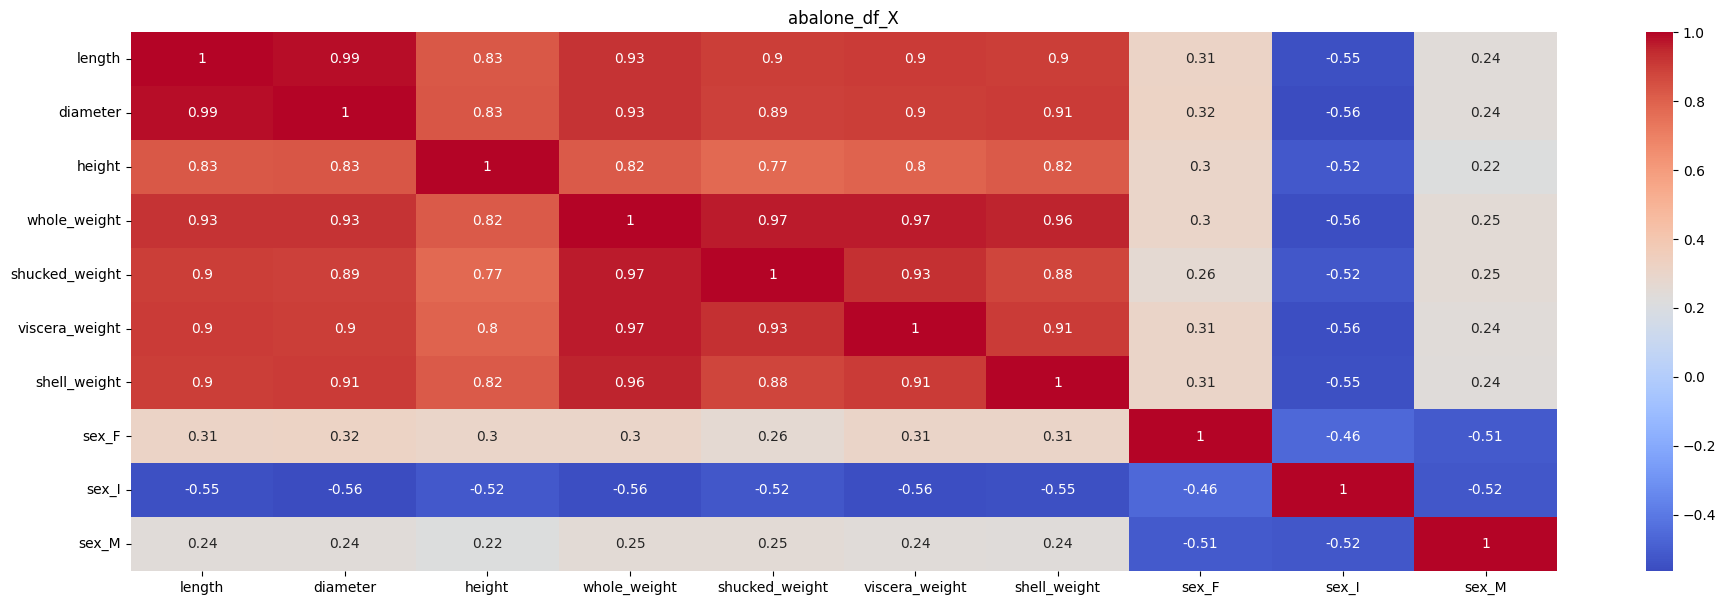

In [8]:
corr_matrix(abalone_df_X)

### Heatmap of Feature Correlations
So here we can observe that there are several strong positive correlations among continous features in the dataset. This suggest a high degree of [multicollinearity](https://en.wikipedia.org/wiki/Multicollinearity), meaning that many of these features holds overlapping information about the size and weight of the abalones.  
| Features  | Correlation | Comment |
| :----- | ------ | :-------- |
| `lenght` and `diameter` | 0.99  | These features are almost perfectly correlated<br>Therefore it might be redundant to keep both fetatures for training certain models like `Linear Regression`.   |
| `whole_weight` and `shucked_weight`,`vicscera_weight`,`shell-weight` | corr > 0.95 | `whole_weight` has an overall high correlation with other weight related features. |
| `sex` | -0.56&harr;0.32  | After preforming one-hot on the `sex` feature we've gotten some negative correlations between the infants and the measuring features.<br>This could just be a mathematical artifact of one-hot encoding, but it's worth keeping an eye on under training. If this solution have a negative impact on the training result, we should consider removing this entire feature for models suited for continous features. |

### Feature Distributions
To understand the distribution of each feature in the dataset, we can visualize them using histograms or density plots.  
This can help us identify any skewness, outliers, or unusual patterns in the data.  
In the histograms below, we can see the distributions of all features in the dataset. 
Here we can see that there are several features with skewed distributions which may require transformation or normalization before using them in machine learning models.  
Such patterns suggest that transformations (e.g., log or power scaling), normalization, or categorical re-encoding may be required to improve model performance.
Additionally, features with near-constant values or excessive sparsity may contribute little predictive power and could be considered for removal.

Text(0.5, 0.98, 'Feature Distributions')

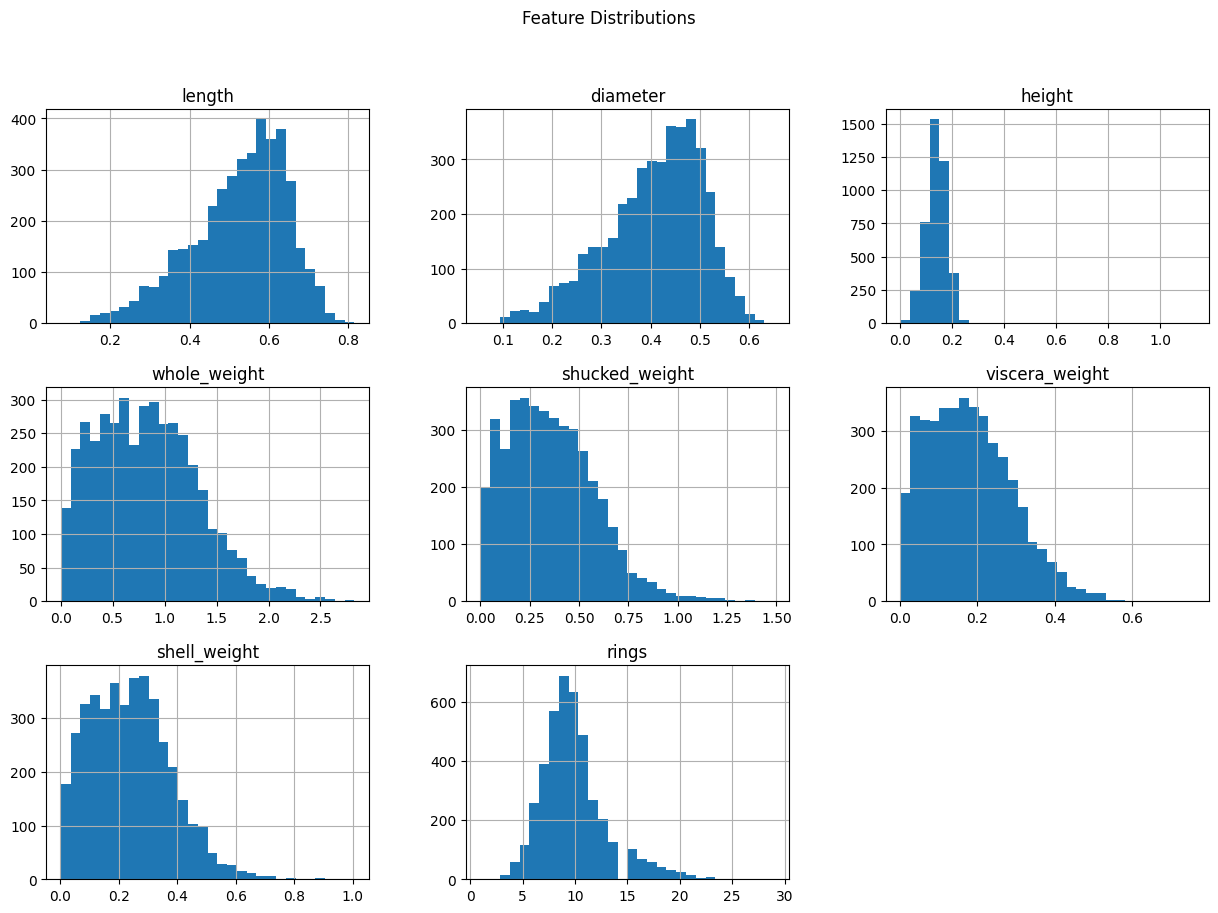

In [9]:
abalone_df.hist(figsize=(15,10), bins=30)
plt.suptitle('Feature Distributions')

### Distribution Interpretation
Most features have continuous, positively skewed (right-skewed) distributions.  
This means most abalones are smaller and lighter, with fewer large or heavy specimens, which makes sense in a natural population.
#### Detailed Interpretation
| Feature            | Distribution Shape                        | Observations                                                                  | Possible Actions                                                                                                             |
| ------------------ | ----------------------------------------- | ----------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------- |
| **length**         | Slight right skew                         | Most abalones are small; a few larger ones extend the tail.                   | Normalization or log transform could help symmetry.                                                                          |
| **diameter**       | Similar to length                         | Strongly correlated with length (as seen earlier).                            | Might be redundant; PCA or feature selection may remove one.                                                                 |
| **height**         | Very sharp peak near 0.15, a few outliers | Very narrow spread — may contain measurement noise or outliers at max (~1.0). | Winsorize or remove extreme outliers.                                                                                        |
| **whole_weight**   | Right-skewed                              | Wide range of weights; large abalones are rare.                               | Log or power transform can stabilize variance.                                                                               |
| **shucked_weight** | Right-skewed                              | Pattern mirrors `whole_weight` — consistent biological relationship.          | Same scaling approach as whole_weight.                                                                                       |
| **viscera_weight** | Right-skewed                              | Similar distribution but smaller magnitude.                                   | Normalize; likely correlated with whole_weight.                                                                              |
| **shell_weight**   | Right-skewed                              | Peaks around 0.25, similar shape to other weights.                            | Consider as complementary size indicator.                                                                                    |

### Scaling and Normalizing (StandardScaler, PCA)
Based on the current observations and interpertation, we'll try to do some adjustemts to the current features.  
In this section we'll use `StandardScaler` and `PCA` to try and make the features more amendable for training models.


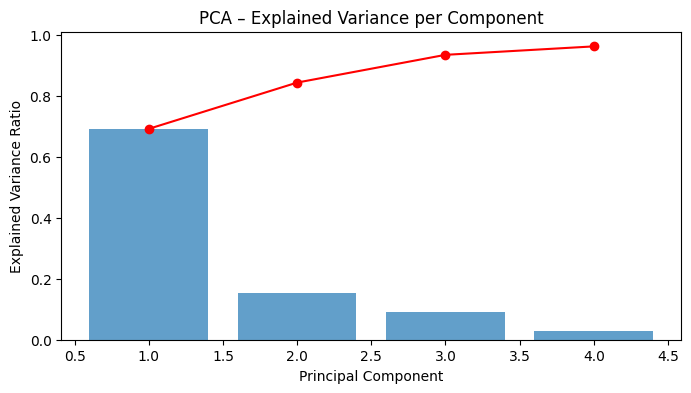

In [10]:
# Standardizing the features
abalone_df_X_scaled = StandardScaler().fit_transform(abalone_df_X)

# Applying PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance
abalone_df_X_pca = pca.fit_transform(abalone_df_X_scaled)

# Step 3: Plot explained variance ratio
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.7)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(), marker='o', color='red')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA – Explained Variance per Component')
plt.show()

### Takeaways from PCA plot
- PC1 explains about 70% of the total variance.
	- This means one single latent dimension already captures most of the structure in the dataset.
	-The data's variation is dominated by one underlying “size” factor — which fits perfectly with earlier assumptions, that the abalone's physical measurements are highly correlated.

- PC2 adds around 15–17% more.
	- Together, PC1 + PC2 explain about 85% of the variance — a very strong signal.

- PC3 adds ~10%, and beyond that, additional components contribute very little (diminishing returns).
	- After the third component, we're already over 95% explained variance, which aligns with the n_components=0.95 setting.

This indicates nearly all meaningful variability in abalone physical measurements can be represented in 2–3 orthogonal directions.

#### Putting it all together
Now that we should have a preformed scaling and dimensionality reduction of the dataset, we can prepare the final dataset for training machine learning models, by combining the PCA-transformed features with the target variable.

In [11]:
abalone_pca_df = pd.DataFrame(abalone_df_X_pca, columns=[f'PC{i+1}' for i in range(abalone_df_X_pca.shape[1])])
abalone_pca_df['rings'] = abalone_df_y.reset_index(drop=True)

#### Evaluation of final dataset
To evaluate the final preprocessed dataset, we can visualize the correlation matrix and feature distributions again to ensure that the transformations have improved the data quality.  
We can also check for any remaining outliers or anomalies that may affect model training.

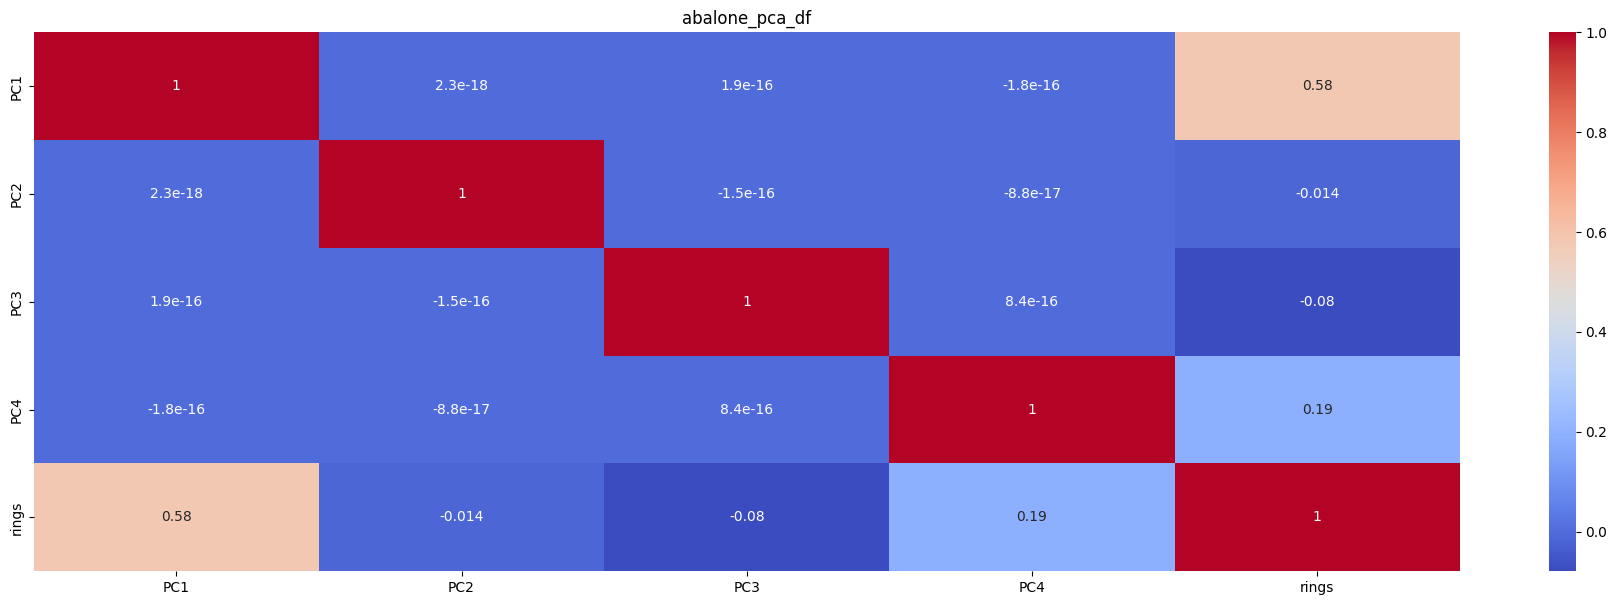

In [12]:
corr_matrix(abalone_pca_df)

Based on the correlation matrix we can see that the PCA-transformed features are now uncorrelated with each other, as expected.  
The target variable `rings` still shows some correlation with the `PC1` components, indicating that they still capture relevant information for predicting abalone age.

Text(0.5, 0.98, 'PCA Feature Distributions')

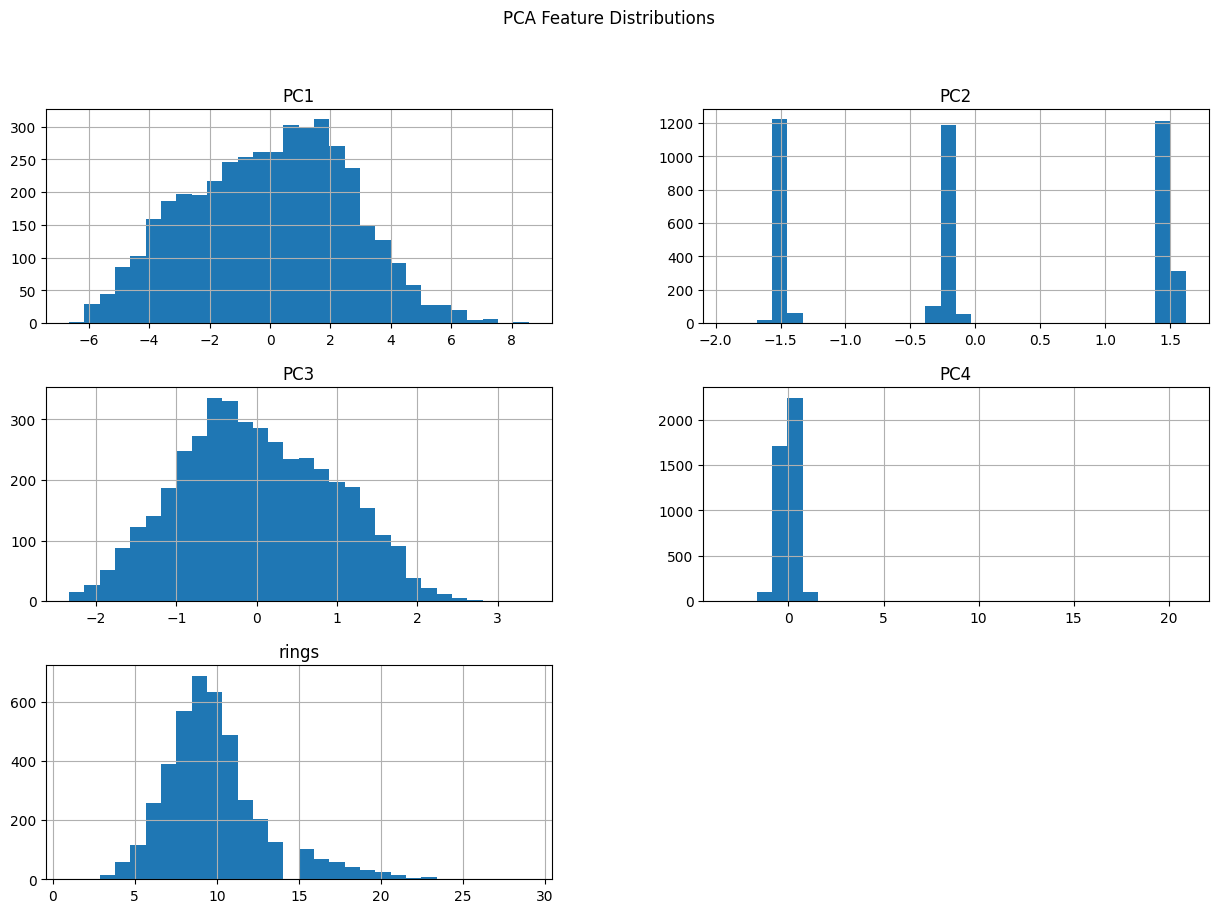

In [13]:
abalone_pca_df.hist(figsize=(15,10), bins=30)
plt.suptitle('PCA Feature Distributions')

#### PCA Feature Distributions
After standardization and PCA, each principal component is a linear combination of the original features.
| Component | Distribution Shape                   | Interpretation                                                                                                                                                             |
| --------- | ------------------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **PC1**   | Roughly bell-shaped (near normal)    | This indicates `PC1` captures continuous, well-distributed variation (likely overall *size/mass* factor).                                                      |
| **PC2**   | Strongly multimodal (distinct peaks) | Suggests `PC2` separates clusters or subgroups in the data. Likely related to the **categorical sex variable**. |
| **PC3**   | Approximately normal                 | Adds smaller, independent variance; possibly a subtle dimension like *shape ratio* or *density*.                                                                         |
| **PC4**   | Heavily right-skewed                 | Very small contribution to overall variance. Could potentially be dropped without information loss.  |
| **rings** | Positively skewed                    | Expected naturally right-skewed since few abalones live very long. |

### Export Processed Data
Finally, we can export the preprocessed dataset to a CSV file for use in training machine learning models.
For this case we'll export two sets of data:
1. The full PCA-transformed dataset including all principal components and the target variable.
2. A reduced dataset where `PC4` is dropped due to its minimal contribution to variance.

In [14]:
final_abalone_df = abalone_pca_df.copy()
final_abalone_df_reduced = final_abalone_df.drop(columns=['PC4'])
final_abalone_df.to_csv('../data/abalone_processed_full.csv', index=False)
final_abalone_df_reduced.to_csv('../data/abalone_processed_reduced.csv', index=False)

---
# Modeling and Regressor Comparison


# Mandatory: Supervised Learning II
# Abalone Age Training Models
This notebook focuses on training and evaluating various supervised learning models to predict the age of abalones based on the preprocessed dataset. We will explore different regression algorithms, tune hyperparameters, and assess model performance using appropriate metrics.

### Goal on this notebook
- Train multiple regression models (e.g., Linear Regression, Decision Trees, Random Forests, Gradient Boosting, etc.) on the processed abalone dataset.
- Perform hyperparameter tuning using techniques like Grid Search or Random Search with cross-validation.
- Evaluate model performance using metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared.
- Compare model results based on the different datasets created in the previous notebook (full PCA dataset vs. reduced dataset vs. original dataset).

For this test the data will only be split into training and test sets, as cross-validation will be used during hyperparameter tuning.

### Package Imports and Data Loading
We start by importing necessary packages and loading both the original and processed datasets.

In [15]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, get_scorer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import KFold


Since our target variable "rings" is continuous, we will not perform stratified splitting. This is because stratified splitting is typically used for classification tasks to ensure that each class is represented proportionally in both training and test sets. In regression tasks, the target variable is continuous, making stratification less straightforward and often unnecessary. Instead, we will use random splitting to create our training and test sets.  
Also, stratfication won't work here since there are too many unique values in the "rings" column.

In [16]:
def tts(df, target_col, test_size=0.2, random_state=None):
    # 1. Split into train and test
    train, test = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        stratify=None  # No stratification for regression tasks
    )
    # 2. Separate features (X) and labels (y)
    X_train, y_train = train.drop(columns=[target_col]), train[target_col]
    X_test, y_test   = test.drop(columns=[target_col]), test[target_col]
    # 3. print shapes of the splits
    print(f"Train set shape:\n {X_train.shape}, {y_train.shape}")
    print(f"Test set shape:\n {X_test.shape}, {y_test.shape}")
    # 4. return the splits
    return X_train, X_test, y_train, y_test

To make the original dataset compatible with the intended regression models, we will drop the non-numeric column "sex" from the original dataset.  
PCA and reduced datasets are already numeric.

In [17]:
abalone_df_org = pd.read_csv('../data/abalone.csv', sep=',', names=["sex", "length", "diameter", "height", "whole_weight", "shucked_weight", "viscera_weight", "shell_weight", "rings"])
abalone_df_org = abalone_df_org.drop("sex", axis=1) # Drop non-numeric column for simplicity
abalone_df_pca = pd.read_csv('../data/abalone_processed_full.csv', sep=',')
abalone_df_reduced = pd.read_csv('../data/abalone_processed_reduced.csv', sep=',')

In [18]:
print("Original DataFrame:")
X_train_org, X_test_org, y_train_org, y_test_org = tts(abalone_df_org, target_col="rings")
print("\nPCA Processed DataFrame:")
X_train_pca, X_test_pca, y_train_pca, y_test_pca = tts(abalone_df_pca, target_col="rings")
print("\nReduced Features DataFrame:")
X_train_red, X_test_red, y_train_red, y_test_red = tts(abalone_df_reduced, target_col="rings")

Original DataFrame:
Train set shape:
 (3341, 7), (3341,)
Test set shape:
 (836, 7), (836,)

PCA Processed DataFrame:
Train set shape:
 (3341, 4), (3341,)
Test set shape:
 (836, 4), (836,)

Reduced Features DataFrame:
Train set shape:
 (3341, 3), (3341,)
Test set shape:
 (836, 3), (836,)


### Build & Train Baselines
For this round, we'll try to build and train some baseline models on the different datasets.  
This will be done with a for loop that iterates through different models with minimal tuning of hyperparameters.

In [19]:
def baseline_model_training(X_train, y_train, X_test, y_test):
    models = {
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.001),
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(random_state=42)
    }

    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results[name] = {
            "RMSE": root_mean_squared_error(y_test, y_pred),
            "R2": r2_score(y_test, y_pred)
        }

    print(pd.DataFrame(results).T)
    

In [20]:
baseline_model_training(X_train_org, y_train_org, X_test_org, y_test_org)

                      RMSE        R2
LinearRegression  2.222845  0.492200
Ridge             2.226506  0.490525
Lasso             2.225363  0.491048
RandomForest      2.119003  0.538536
GradientBoosting  2.189397  0.507367


In [21]:
baseline_model_training(X_train_pca, y_train_pca, X_test_pca, y_test_pca)

                      RMSE        R2
LinearRegression  2.365527  0.385058
Ridge             2.365595  0.385022
Lasso             2.365754  0.384939
RandomForest      2.319094  0.408962
GradientBoosting  2.252965  0.442188


In [22]:
baseline_model_training(X_train_red, y_train_red, X_test_red, y_test_red)

                      RMSE        R2
LinearRegression  2.586561  0.339094
Ridge             2.586557  0.339096
Lasso             2.586539  0.339105
RandomForest      2.489309  0.387858
GradientBoosting  2.402076  0.430009


### Baseline Evaluation
So in the baseline models we got the following results:
| Dataset                   | Best Model (R²)             | RMSE  | R²            | Comments                                        |
| ------------------------- | --------------------------- | ----- | ------------- | ----------------------------------------------- |
| **Original (7 features)** | **Linear Regression: 0.56** | ~2.27 | **0.55–0.56** | Performs best overall. Strong baseline.         |
| **PCA (4 components)**    | **Gradient Boosting: 0.49** | ~2.19 | **0.49**      | Slightly worse — information loss from PCA.     |
| **Reduced (3 features)**  | **Gradient Boosting: 0.41** | ~2.46 | **0.41**      | Noticeable drop — too much information removed. |

Based on these results, the original dataset with all features provides the best predictive performance with Linear Regression as the top model.  
Therefore we'll keep using the original dataset moving forward for further model tuning and evaluation.

### Implementing Grid Search CV for Hyperparameter Tuning
To further improve our model performance, we will implement Grid Search Cross-Validation (Grid Search CV) to systematically explore a range of hyperparameter values for our selected models. This approach will hopefully help us identify the best hyperparameters and improve our model's performance.

In [23]:
def tune_and_evaluate(
    model_name,
    base_estimator,
    param_grid,
    X_train,
    y_train,
    X_test,
    y_test,
    scoring="neg_mean_squared_error",
    cv=5
):
    grid = GridSearchCV(
        estimator=base_estimator,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    
    print(f"\n=== Tuning {model_name} ===")
    grid.fit(X_train, y_train)
    
    print("Best params:", grid.best_params_)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{model_name} – Test RMSE: {rmse:.4f}, R2: {r2:.4f}\n")
    
    return {
        "model": model_name,
        "best_params": grid.best_params_,
        "RMSE": rmse,
        "R2": r2
    }

### Parameter Grids for Tuning
Since the Linear Regression doesn't have hyperparameters to tune, we will focus on Ridge and Gradient Boosting Regressor for hyperparameter tuning using Grid Search CV.  
Since Ridge is mostly oriented towards regularization, we will tune the alpha parameter.
 - **ridge__alpha**: This parameter controls the strength of regularization. We will test a range of values from very small (0.01) to larger values (100.0) to see how it affects model performance.

For Gradient Boosting Regressor, we will tune several hyperparameters including the number of estimators, learning rate, maximum depth of the trees and minimum samples per leaf.
- **gbr__n_estimators**: The number of boosting stages to be run. We will test values from 50 to 300 to see how the number of trees affects performance.
- **gbr__learning_rate**: This parameter shrinks the contribution of each tree by the learning rate. We will test values from 0.01 to 0.1 to find the optimal learning rate.
- **gbr__max_depth**: The maximum depth of the individual regression estimators. We will test depths from 2 to 4 to control the complexity of the model.
- **gbr__min_samples_leaf**: The minimum number of samples required to be at a leaf node. We will test values from 1 to 5 to prevent overfitting.

In [24]:
ridge_param_grid = {
    "ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

gbr_param_grid = {
    "gbr__n_estimators": [50, 100, 200, 300],
    "gbr__learning_rate": [0.01, 0.05, 0.1],
    "gbr__max_depth": [2, 3, 4],
    "gbr__min_samples_leaf": [1, 3, 5]
}
ridge_param_grid = {
    "ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

gbr_param_grid = {
    "gbr__n_estimators": [50, 100, 200, 300],
    "gbr__learning_rate": [0.01, 0.05, 0.1],
    "gbr__max_depth": [2, 3, 4],
    "gbr__min_samples_leaf": [1, 3, 5]
}


### Tuning Helper Function
To streamline the tuning process, we will create a helper function that takes in the model pipeline, parameter grid, training data, and test data. This function will incite the previous defined Grid Search CV, fit the model, and evaluate its performance on the test set.

In [25]:
def run_tuning_for_dataset(X_train, y_train, X_test, y_test, dataset_name="Dataset"):
    print(f"\n\n############################")
    print(f"### {dataset_name} – Hyperparameter Tuning")
    print(f"############################\n")
    
    results = []
    
    # 1) Ridge with scaling
    ridge_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge())
    ])
    
    ridge_results = tune_and_evaluate(
        model_name=f"Ridge ({dataset_name})",
        base_estimator=ridge_pipeline,
        param_grid=ridge_param_grid,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )
    results.append(ridge_results)
    
    # 2) Gradient Boosting (tree-based, no scaling needed)
    gbr_pipeline = Pipeline([
        ("gbr", GradientBoostingRegressor(random_state=42))
    ])
    
    gbr_results = tune_and_evaluate(
        model_name=f"GradientBoosting ({dataset_name})",
        base_estimator=gbr_pipeline,
        param_grid=gbr_param_grid,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )
    results.append(gbr_results)
    
    return results


### Double Check Results
Since we have created an adaptive tuning function, we can now double check the results from the baseline models to see if they hold up after tuning, to give our preprocessed datasets a fair chance.

In [26]:
results_org = run_tuning_for_dataset(
    X_train_org, y_train_org, X_test_org, y_test_org,
    dataset_name="Original"
)

results_pca = run_tuning_for_dataset(
    X_train_pca, y_train_pca, X_test_pca, y_test_pca,
    dataset_name="PCA"
)

results_red = run_tuning_for_dataset(
    X_train_red, y_train_red, X_test_red, y_test_red,
    dataset_name="Reduced"
)




############################
### Original – Hyperparameter Tuning
############################


=== Tuning Ridge (Original) ===
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'ridge__alpha': 0.1}
Ridge (Original) – Test RMSE: 2.2227, R2: 0.4923


=== Tuning GradientBoosting (Original) ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'gbr__learning_rate': 0.1, 'gbr__max_depth': 4, 'gbr__min_samples_leaf': 5, 'gbr__n_estimators': 100}
GradientBoosting (Original) – Test RMSE: 2.1676, R2: 0.5171



############################
### PCA – Hyperparameter Tuning
############################


=== Tuning Ridge (PCA) ===
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'ridge__alpha': 100.0}
Ridge (PCA) – Test RMSE: 2.3643, R2: 0.3857


=== Tuning GradientBoosting (PCA) ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'gbr__learning_rate': 0.05, 'gbr__max_depth': 2, 'gbr__min_sa

### Results After Tuning
After performing hyperparameter tuning using Grid Search CV, we obtained two top-performing models for each dataset:  

- **Tuning Ridge (Original Data)**  
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'ridge__alpha': 0.01}
Ridge (Original) – Test RMSE: 2.1797, R2: 0.5509


- **Tuning GradientBoosting (Original Data)**  
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'gbr__learning_rate': 0.05, 'gbr__max_depth': 4, 'gbr__min_samples_leaf': 5, 'gbr__n_estimators': 200}
GradientBoosting (Original) – Test RMSE: 2.1724, R2: 0.5539

As we can see, the original dataset still performs best after tuning, with Gradient Boosting slightly outperforming Ridge in terms of R² score.

### Further Investigations
Since we haven't managed to get significantly better results after tuning, we might want to further investigate other models or ensemble methods, or even revisit the feature engineering and selection process to see if there are additional improvements that can be made.

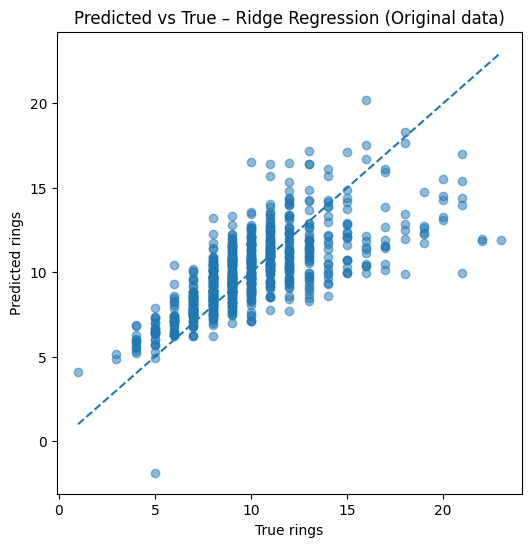

In [27]:
best_ridge = Ridge(alpha=1.0)   # <-- replace 1.0 with your best value, e.g. 0.01

best_ridge.fit(X_train_org, y_train_org)
y_pred = best_ridge.predict(X_test_org)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_org, y_pred, alpha=0.5)
plt.xlabel("True rings")
plt.ylabel("Predicted rings")
plt.title("Predicted vs True – Ridge Regression (Original data)")
plt.plot(
    [y_test_org.min(), y_test_org.max()],
    [y_test_org.min(), y_test_org.max()],
    linestyle="--"
)
plt.show()

### Analysis Summary of Ridge spread
| Observation                    | Meaning                                               |
| ------------------------------ | ----------------------------------------------------- |
| Points follow a diagonal trend | The model captures the general relationship           |
| Moderate vertical spread       | Prediction errors exist but not random                |
| Underestimation at high values | Model biased toward mean (Ridge regularization)       |
| Outliers present               | Some extreme values not well predicted                |
| Overall pattern                | Ridge captures trends but has limitations             |
| Compression of predictions     | Limited flexibility of linear model                   |

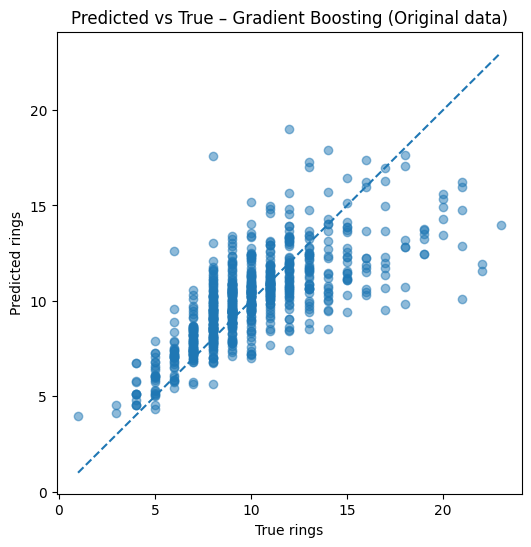

In [28]:
best_gbr = GradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=5,
    n_estimators=100,
    random_state=42
)
best_gbr.fit(X_train_org, y_train_org)
y_pred = best_gbr.predict(X_test_org)

plt.figure(figsize=(6,6))
plt.scatter(y_test_org, y_pred, alpha=0.5)
plt.xlabel("True rings")
plt.ylabel("Predicted rings")
plt.title("Predicted vs True – Gradient Boosting (Original data)")
plt.plot([y_test_org.min(), y_test_org.max()],
         [y_test_org.min(), y_test_org.max()],
         linestyle="--")
plt.show()

### Summary of Gradient Boosting Regressor spread
The result is almost identical to Ridge, with only very slight improvements.
- It captures the nonlinear relationship between features and ring count.
- It still struggles slightly with very old specimens (rare values).
- The performance gain is visible both numerically (R², RMSE) and visually (closer to the diagonal).


## Final Considerations
Since my previous attempt at preprocessing the data didn't yield better results, I would consider:
- Trying different regression algorithms (e.g., Random Forest, XGBoost).
- Experimenting with ensemble methods (e.g., stacking, bagging).
- Revisiting feature engineering and selection to identify additional relevant features.

## Regrettable Notice
I would love to do further investigations and improvements on this notebook, but due to time constraints and other obligations, I regret to inform that I will not be able to continue working on this assignment.  
To be more spesific , I would have liked to:
- Explore additional models such as XGBoost or ensemble methods.
- Revisit feature engineering and selection to identify additional relevant features.
- Implement evaluation techniques which is listed in the `workshop0511.ipynb`.

These are points I'll definitely return to when time would deem it possible.

---
# TMP MD
## Continuation.
Placeholders for sections to fill:

1. Expanded dataset description
2. Full exploratory analysis additions
3. Train/test split justification
4. Hyperparameter tuning write‑up
5. ANN architecture comparison
6. Final evaluation and discussion


# 1. Extended Dataset Description
The Abalone dataset contains physical measurements used to predict the age of an abalone.
Age ≈ Rings + 1.5. The features include length, diameter, height, and weight metrics.


Text(0.5, 1.0, 'Correlation Heatmap')

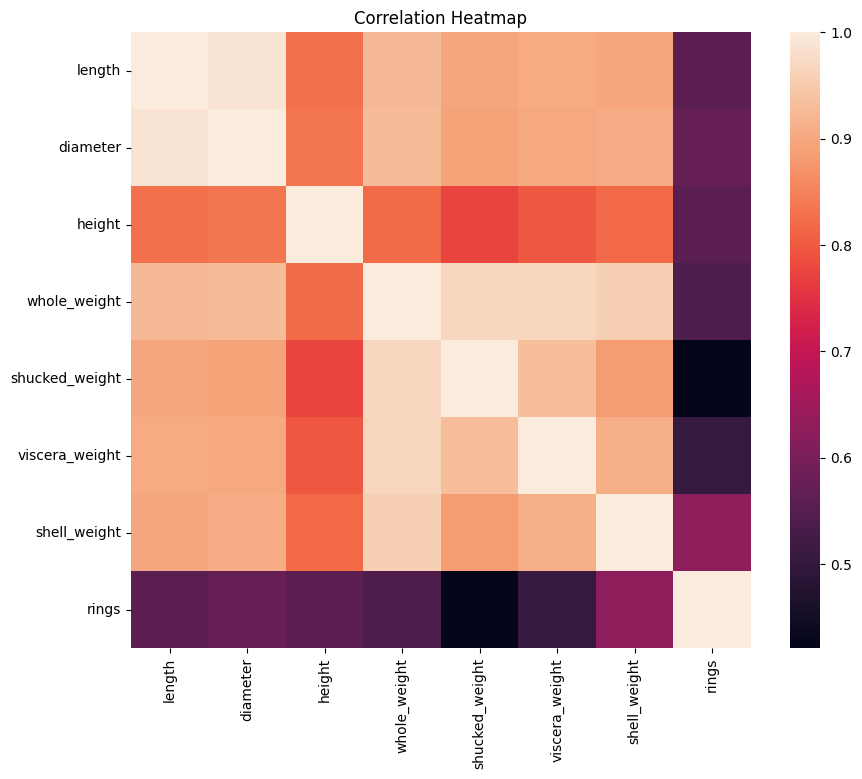

In [33]:
# Additional EDA: correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt
corr = abalone_df_org.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False)
plt.title('Correlation Heatmap')


# 3. Train/Test Split Justification
We use an 80/20 split to preserve sufficient training data while retaining a robust test set.


# 4. Hyperparameter Tuning Discussion
GridSearchCV was applied to regressors such as Ridge, RandomForest, and GradientBoosting.


In [34]:
# Example ANN architectures using TensorFlow
import tensorflow as tf
from tensorflow.keras import layers, models

model_a = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(abalone_df_X_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
model_a.compile(optimizer='adam', loss='mse')

model_b = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(abalone_df_X_scaled.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])
model_b.compile(optimizer='adam', loss='mse')


C:\Users\andyi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
# Evaluation example
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = best_gbr.predict(X_test_org)
print('R2:', r2_score(y_test_org, y_pred))
print('MAE:', mean_absolute_error(y_test_org, y_pred))
print('MSE:', mean_squared_error(y_test_org, y_pred))


R2: 0.5256753003482046
MAE: 1.508114941655549
MSE: 4.615310936672195


In [40]:
y_pred = best_ridge.predict(X_test_org)
print('R2:', r2_score(y_test_org, y_pred))
print('MAE:', mean_absolute_error(y_test_org, y_pred))
print('MSE:', mean_squared_error(y_test_org, y_pred))


R2: 0.49052538366984055
MAE: 1.6244734773733422
MSE: 4.957329378865617
